In [3]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
 
from RENDES_fizinfo import *

In [4]:
def motor_r(t):
    phi=(2*np.pi/9)*t
    R=8+1.5*np.sin(2*np.pi/2.5*t)
    x=R*np.cos(phi)
    y=R*np.sin(phi)
    
    return np.array([x, y], np.float64)

In [5]:
# a) Ábrázolja a motor pályáját az első hét körben
motor=num_kinem(2)   # 2D kinematikai számítások

# rajzolja a pályát le az első 7 kör alatt
# 1 kör a 9mp mivel a phi-ben a 2pi-t tehát egy kört 9mp alatt teszi meg 9*7 = 64
motor.set_time_range(0.0, 64.0, 0.01)

motor.set_r_fun(motor_r)
motor.calc_r_to_v()
motor.calc_v_to_a()

#motor.plot_rcomp()

In [6]:
# Mennyi a motor legnagyobb és legkisebb gyorsulása? (gyorsulás-vektorának abszolút értéke)?

motor.calc_at_acp_Rinv()

# a teljes gyorsulásvektor nagysága a Pitagorasz-tétel alapján:
# a_t_abs: ELŐJELES szám (pozitív = gyorsít, negatív = fékez) → négyzetre emelve előjel nem számít
# a_cp_abs: mindig pozitív (centripetális gyorsulás iránya mindig befelé mutat, nagysága nem negatív)
# a négyzetük összegének gyöke adja a teljes gyorsulásvektor hosszát
motor_gyors_abs = np.sqrt(motor.a_t_abs**2 + motor.a_cp_abs**2)

motor_max_gyors = motor_gyors_abs.max()  # legnagyobb gyorsulás nagysága
motor_min_gyors = motor_gyors_abs.min()  # legkisebb gyorsulás nagysága

print(f'A motor legnagyobb gyorsulása: {motor_max_gyors:.2f} m/s^2')
print(f'A motor legkisebb gyorsulása: {motor_min_gyors:.2f} m/s^2')

A motor legnagyobb gyorsulása: 14.10 m/s^2
A motor legkisebb gyorsulása: 2.36 m/s^2


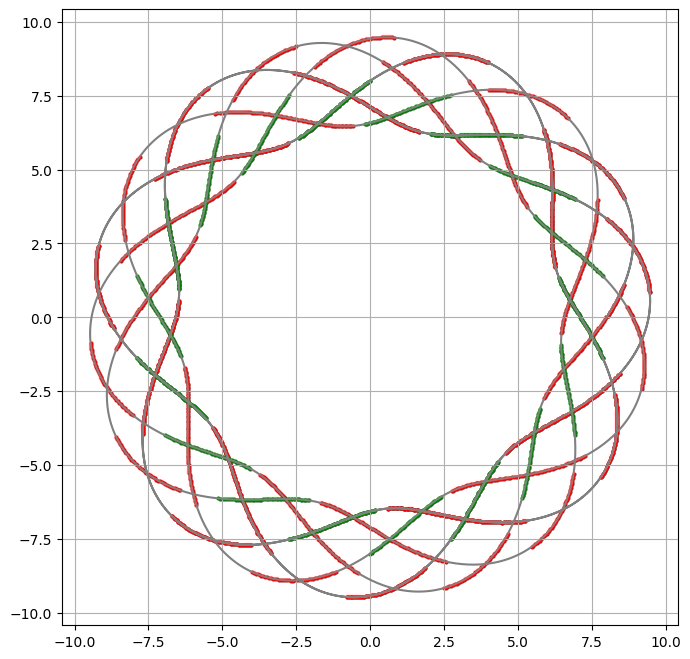

In [7]:
# c) Készítsen ábrát, melyen a motor pályája szürke, 
# és rajta pirossal be vannak jelölve azok a szakaszok, 
# ahol növekszik a motoros sebességének nagysága (azaz az átlagosnál jobban kell gázt adnia), 
# zölddel pedig azok, ahol a sebesség jelentősen csökken (4 p)

# átlagos pozitív (gyorsító) tangenciális gyorsulás küszöbként
#gyorsitasi_atlag = np.average(motor.a_t_abs[motor.a_t_abs > 0])
# bool maszk: ahol a gyorsulás meghaladja az átlagos gyorsítást
motor_gyorsit_maszk = motor.a_t_abs > 0.0

# átlagos fékezési gyorsulás nagysága küszöbként (csak a negatív értékekből)
fekezesi_atlag = np.average(np.abs(motor.a_t_abs[motor.a_t_abs < 0]))
# bool maszk: ahol a fékezés erősebb az átlagosnál (a_t_abs negatív fékezésnél)
motor_eros_fekezes_maszk = motor.a_t_abs < -fekezesi_atlag

fig = plt.figure(figsize=(8,8))  
ax1 = plt.subplot(111)

ax1.plot(motor.r[:,0], motor.r[:,1], color="grey")        # teljes pályagörbe
ax1.scatter(motor.r[motor_gyorsit_maszk, 0],
            motor.r[motor_gyorsit_maszk, 1],
            color="red", s=4)                             # átlag feletti gyorsítási szakaszok

ax1.scatter(motor.r[motor_eros_fekezes_maszk, 0],
            motor.r[motor_eros_fekezes_maszk, 1],
            color="green", s=4)                           # átlag feletti fékezési szakaszok

ax1.set_aspect(aspect="equal")
ax1.grid()

In [8]:
# Állapítsa meg hogy az idő hány százalékában halad a motor gyorsabban, mint az átlagos sebességnagyság!

motor.v_abs = vect_abs(motor.v)  # sebességvektor nagysága minden időpontban

motor_v_avg = np.average(motor.v_abs)  # átlagos sebességnagyság küszöbként
ossz_ido = motor.t[-1]                 # teljes menetidő (t=0-tól az utolsó időpontig)

v_nagyobb_atlagnal = motor.v_abs > motor_v_avg  # bool maszk: hol v > átlag

dt = motor.t[1:] - motor.t[:-1]  # lépésenkénti időközök

# [:-1]: a maszk eggyel hosszabb mint dt, ezért le kell vágni az utolsó elemet
motor_v_nagyobb_mint_atlag_ossz_ido = dt[v_nagyobb_atlagnal[:-1]].sum()  # átlag feletti időközök összege

print(f'A motor az idő {motor_v_nagyobb_mint_atlag_ossz_ido / ossz_ido * 100:.2f}%-ában halad gyorsabban az átlagnál.')

A motor az idő 63.95%-ában halad gyorsabban az átlagnál.


In [9]:
# Állapítsa meg hány százalékkal hosszabb egy hullámzó kör annál,
# mintha végig szabályosan 8 m sugarú körön haladna a motor.
# Egy kör 9 s, tehát a hullámzó kör hossza a 0-9 s közötti megtett út.

motor.calc_pathlength()

# A 9 másodperchez tartozó index megkeresése
idx_9 = arg_eq(motor.t, 9)[0]

# Hullámzó kör hossza
egy_kor_m = motor.pathlength[idx_9]

# Szabályos 8 m sugarú kör kerülete
szabalyos_kor_m = 2 * np.pi * 8

# Százalékos növekedés
hosszabb_szazalek = (egy_kor_m / szabalyos_kor_m - 1) * 100

print(f"Egy hullámzó kör hossza: {egy_kor_m:.2f} m")
print(f"Egy szabályos 8 m sugarú kör hossza: {szabalyos_kor_m:.2f} m")
print(f"A hullámzó kör {hosszabb_szazalek:.2f}%-kal hosszabb.")


Egy hullámzó kör hossza: 56.43 m
Egy szabályos 8 m sugarú kör hossza: 50.27 m
A hullámzó kör 12.27%-kal hosszabb.
